Создаем граф

In [1]:
import networkx as nx
import numpy as np

nodes = ['Сплоченность коллектива',
         'Сроки',
         'Качество продукта',
          'Конкуренция',
         'Эффективность',
         'Универсальность',
         'ЗП сотрудников',
         'Скиллы сотрудников',
         'Спрос',
         'Бюджет',
         ]

edges = [
   ('Сплоченность коллектива','Сроки', '-1'),
   ('Сплоченность коллектива','Эффективность',  '+1'),
   ('Качество продукта','Спрос',  '+1'),
   ('Конкуренция','Сроки', '-1'),
   ('Конкуренция','Спрос', '-1'),
   ('Эффективность','Качество продукта', '+1'),
   ('Эффективность','Сроки', '-1'),
   ('Универсальность','Конкуренция', '-1'),
   ('ЗП сотрудников','Скиллы сотрудников', '+1'),
   ('Бюджет','ЗП сотрудников', '+1'),
   ('Скиллы сотрудников','Сроки', '-1'),
   ('Скиллы сотрудников','Качество продукта', '+1'),
   ('Спрос','Бюджет', '+1')
   ]

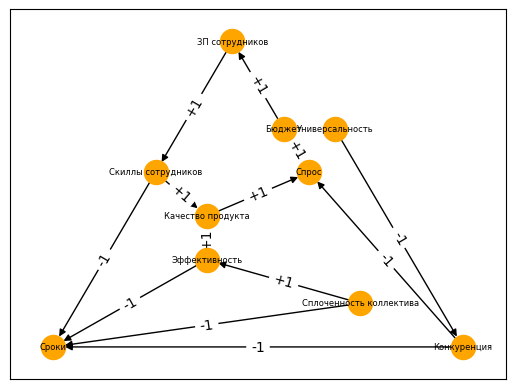

In [2]:
G = nx.DiGraph()

G.add_nodes_from(nodes)
G.add_weighted_edges_from(edges)

pos = nx.planar_layout(G)

draw = nx.draw_networkx(G, pos, node_color='orange', font_size=6)

labels = nx.get_edge_attributes(G,'weight')
draw = nx.draw_networkx_edge_labels(G,pos, edge_labels=labels)

Модель построена, теперь проанализируем:

In [3]:
labels

{('Сплоченность коллектива', 'Сроки'): '-1',
 ('Сплоченность коллектива', 'Эффективность'): '+1',
 ('Качество продукта', 'Спрос'): '+1',
 ('Конкуренция', 'Сроки'): '-1',
 ('Конкуренция', 'Спрос'): '-1',
 ('Эффективность', 'Качество продукта'): '+1',
 ('Эффективность', 'Сроки'): '-1',
 ('Универсальность', 'Конкуренция'): '-1',
 ('ЗП сотрудников', 'Скиллы сотрудников'): '+1',
 ('Скиллы сотрудников', 'Сроки'): '-1',
 ('Скиллы сотрудников', 'Качество продукта'): '+1',
 ('Спрос', 'Бюджет'): '+1',
 ('Бюджет', 'ЗП сотрудников'): '+1'}

In [4]:
cycles = [(labels[i],i) for i in nx.find_cycle(G)]
print(*cycles, sep='\n')
# Оказалось, что у нас только один цикл
print("\nМодель структурно устойчива" if [i[0] for i in cycles].count('-1')%2 else "\nМодель структурно неустойчива")

('+1', ('Качество продукта', 'Спрос'))
('+1', ('Спрос', 'Бюджет'))
('+1', ('Бюджет', 'ЗП сотрудников'))
('+1', ('ЗП сотрудников', 'Скиллы сотрудников'))
('+1', ('Скиллы сотрудников', 'Качество продукта'))

Модель структурно неустойчива


In [5]:
labels_weights = nx.get_edge_attributes(G,'weight')
matrix = [[int(labels_weights.get((i,j),0)) for j in nodes] for i in nodes]
matrix

[[0, -1, 0, 0, 1, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
 [0, -1, 0, 0, 0, 0, 0, 0, -1, 0],
 [0, -1, 1, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, -1, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
 [0, -1, 1, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
 [0, 0, 0, 0, 0, 0, 1, 0, 0, 0]]

In [6]:
evalue, evect = np.linalg.eig(matrix)
print(np.max(evalue)," <== максимальный корень характ. уравнения\n", abs(np.max(evalue)), " <== модуль этого корня")

(0.9999999999999997+0j)  <== максимальный корень характ. уравнения
 0.9999999999999997  <== модуль этого корня


Максимальный корень характеристического уравнения <1, а значит система устойчива по возмущению и по начальному значению

Перейдем к импульсному моделированию...
ппу пу пу......

In [7]:
def V(t, original_v, imp, matr):
    res =  np.eye(10,10)
    m = matr.copy()

    Vn = [original_v]
    print("V0 = ",Vn[-1])
    Pn = [imp]
    Vn += [np.add.reduce([res.T.dot(imp), original_v])]
    print("V1 = ",Vn[-1])
    for i in range(t-1):
      Pn.append(matr.T.dot(Pn[-1]))
      Vn.append(Vn[-1]+Pn[-1])
      print(f"V{i+2} = ",Vn[-1])
    print("****************************************************")
    return Vn

impulse = np.array([0 for i in range(len(nodes))])
impulse[-1] = 1
original_v = np.zeros(10)
A = np.array(matrix)
Vn = V(10, original_v, impulse, A)
print(*Vn, sep='\n')

V0 =  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
V1 =  [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
V2 =  [0. 0. 0. 0. 0. 0. 1. 0. 0. 1.]
V3 =  [0. 0. 0. 0. 0. 0. 1. 1. 0. 1.]
V4 =  [ 0. -1.  1.  0.  0.  0.  1.  1.  0.  1.]
V5 =  [ 0. -1.  1.  0.  0.  0.  1.  1.  1.  1.]
V6 =  [ 0. -1.  1.  0.  0.  0.  1.  1.  1.  2.]
V7 =  [ 0. -1.  1.  0.  0.  0.  2.  1.  1.  2.]
V8 =  [ 0. -1.  1.  0.  0.  0.  2.  2.  1.  2.]
V9 =  [ 0. -2.  2.  0.  0.  0.  2.  2.  1.  2.]
V10 =  [ 0. -2.  2.  0.  0.  0.  2.  2.  2.  2.]
****************************************************
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
[0. 0. 0. 0. 0. 0. 1. 0. 0. 1.]
[0. 0. 0. 0. 0. 0. 1. 1. 0. 1.]
[ 0. -1.  1.  0.  0.  0.  1.  1.  0.  1.]
[ 0. -1.  1.  0.  0.  0.  1.  1.  1.  1.]
[ 0. -1.  1.  0.  0.  0.  1.  1.  1.  2.]
[ 0. -1.  1.  0.  0.  0.  2.  1.  1.  2.]
[ 0. -1.  1.  0.  0.  0.  2.  2.  1.  2.]
[ 0. -2.  2.  0.  0.  0.  2.  2.  1.  2.]
[ 0. -2.  2.  0.  0.  0.  2.  2.  2.  2.]


In [8]:
print(*[(i,j) for i,j in enumerate(nodes)], sep='\n')

(0, 'Сплоченность коллектива')
(1, 'Сроки')
(2, 'Качество продукта')
(3, 'Конкуренция')
(4, 'Эффективность')
(5, 'Универсальность')
(6, 'ЗП сотрудников')
(7, 'Скиллы сотрудников')
(8, 'Спрос')
(9, 'Бюджет')


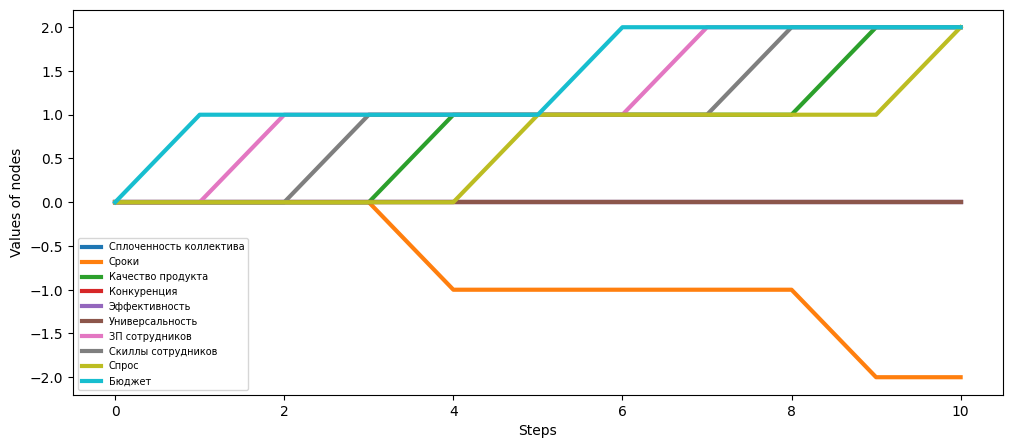

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot(Vn, linewidth=3)
plt.xlabel('Steps')
plt.ylabel('Values of nodes')
plt.legend(labels=nodes, loc='lower left', fontsize=7)
plt.show()